# Diffusers + AbyssOrangeMixs + Bloody Thorn

### AbyssOrangeMix2 (AOM2) HuggingFace
https://huggingface.co/WarriorMama777/OrangeMixs

### Prompts guide
https://www.reddit.com/r/WaifuDiffusion/comments/xudcdp/prompts_guide_by_cdcruz/

### Real-ESRGAN Huggingface Demo
https://huggingface.co/spaces/havas79/Real-ESRGAN_Demo

In [ ]:
try:
    import diffusers
except:
    !pip install -q transformers==4.25.1
    
    !pip install -q accelerate==0.15.0
    !pip install -q diffusers==0.11.1
    !pip install -q huggingface_hub==0.12.0

import diffusers
import huggingface_hub 

import os
import shutil
import time

import torch
import matplotlib.pyplot as plt
import numpy as np

if torch.backends.mps.is_available():
    device_name = torch.device("mps")
if torch.cuda.is_available():
    device_name = torch.device("cuda")
else:
    device_name = torch.device("cpu")

print("Using {}.".format(device_name))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 37.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 24.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.5/191.5 KB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.9/524.9 KB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 7.6 MB/s eta 0:00:00
Using cuda.


## Downloading Model Files from OrangeMixs

In [ ]:
def get_orangemixs_files(repo_id = "WarriorMama777/OrangeMixs", 
                         model_name = "AbyssOrangeMix2",
                         model_dir = None,
                         revision = "main"):
    """Downloads model files from WarriorMama777/OrangeMixs, preserving the directory structure
    for the diffusers library to use.
    
    There must be a simpler way to do this!
    """
    if model_dir is None:
        model_dir = model_name

    os.makedirs(model_dir, exist_ok = True)

    # Download model_index.json config file.
    path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                           filename = "model_index.json", 
                                           revision = revision,
                                           cache_dir = "./")
    
    shutil.copy2(path, "{}/model_index.json".format(model_dir))

    # Download feature_extractor config file.
    part_name = "feature_extractor"
    filename = "Models/{}/Diffusers/{}/preprocessor_config.json".format(model_name, part_name)
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)

    path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                           filename = filename, 
                                           revision = revision,
                                           cache_dir = "./")
    shutil.copy2(path, "{}/{}/preprocessor_config.json".format(model_dir, part_name))

    # Download safety_checker files.
    part_name = "safety_checker"
    files = ["config.json", "pytorch_model.bin"]
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)

    for f in files:
        filename = "Models/{}/Diffusers/{}/{}".format(model_name, part_name, f)
        path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                               filename = filename,
                                               revision = revision,
                                               cache_dir = "./")
        shutil.copy2(path, "{}/{}/{}".format(model_dir, part_name, f))

    # Download scheduler config file.
    part_name = "scheduler"
    filename = "Models/{}/Diffusers/{}/scheduler_config.json".format(model_name, part_name)
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)

    path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                           filename = filename,
                                           revision = revision,
                                           cache_dir = "./")
    shutil.copy2(path, "{}/{}/scheduler_config.json".format(model_dir, part_name))

    # Download text_encoder files.
    part_name = "text_encoder"
    files = ["config.json", "pytorch_model.bin"]
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)

    for f in files:
        filename = "Models/{}/Diffusers/{}/{}".format(model_name, part_name, f)
        path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                               filename = filename,
                                               revision = revision,
                                               cache_dir = "./")
        shutil.copy2(path, "{}/{}/{}".format(model_dir, part_name, f))

    # Download tokenizer files.
    part_name = "tokenizer"
    files = ["merges.txt", "special_tokens_map.json", "tokenizer_config.json", "vocab.json"]
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)

    for f in files:
        filename = "Models/{}/Diffusers/{}/{}".format(model_name, part_name, f)
        path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                               filename = filename,
                                               revision = revision,
                                               cache_dir = "./")
        shutil.copy2(path, "{}/{}/{}".format(model_dir, part_name, f))

    # Download unet.
    part_name = "unet"
    files = ["config.json", "diffusion_pytorch_model.bin"]
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)
    for f in files:
        filename = "Models/{}/Diffusers/{}/{}".format(model_name, part_name, f)
        path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                               filename = filename,
                                               revision = revision,
                                               cache_dir = "./")
        shutil.copy2(path, "{}/{}/{}".format(model_dir, part_name, f))

    # Download vae.
    part_name = "vae"
    os.makedirs(os.path.join(model_dir, part_name), exist_ok = True)
    files = ["config.json", "diffusion_pytorch_model.bin"]
    for f in files:
        filename = "Models/{}/Diffusers/{}/{}".format(model_name, part_name, f)
        path = huggingface_hub.hf_hub_download(repo_id = repo_id, 
                                               filename = filename,
                                               revision = revision,
                                               cache_dir = "./")
        shutil.copy2(path, "{}/{}/{}".format(model_dir, part_name, f))

    return model_dir

In [ ]:
model_dir = "downloaded_model"
if not os.path.exists(model_dir):
    model_dir = get_orangemixs_files(repo_id = "WarriorMama777/OrangeMixs", model_name = "AbyssOrangeMix2", model_dir = model_dir)

In [ ]:
print("Files downloaded to {}.".format(model_dir))

Files downloaded to downloaded_model.


In [ ]:
#!zip -r "AbyssOrangeMix2.zip" "downloaded_model"

## Utility Functions

In [ ]:
# Load (text to image) diffuser pipeline.
def load_pipeline(model_dir, scheduler = None, device_name = torch.device("cpu"), torch_dtype = torch.float32):
    pipe = diffusers.StableDiffusionPipeline.from_pretrained(model_dir, torch_dtype = torch_dtype)

    if scheduler is None or scheduler in ["EulerAncestralDiscreteScheduler", "EADS"]:
        pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["EulerDiscreteScheduler", "EDS"]:
        pipe.scheduler = diffusers.EulerDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["DPMSolverMultistepScheduler", "DPMSMS"]:
        pipe.scheduler = diffusers.DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

# Load image to image diffuser pipeline.
def load_img2img_pipeline(model_dir, device_name = torch.device("cpu"), torch_dtype = torch.float32):
    pipe = diffusers.StableDiffusionImg2ImgPipeline.from_pretrained(model_dir, torch_dtype = torch_dtype)
    pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

In [ ]:
# Run diffuser pipeline.
def run_pipe(pipe, prompt, negative_prompt = None, steps = 60, 
             width = 512, height = 704, scale = 8.0, seed = 123, n_images = 1,
             device_name = torch.device("cpu")):
    if width % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        width = int(width / 8) * 8
    if height % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        height = int(height / 8) * 8

    gen = torch.Generator(device = device_name).manual_seed(seed)
    image_list = []
    with torch.autocast("cuda"): 
        for i in range(n_images): 
            image = pipe(prompt, height = height, width = width, 
                         num_inference_steps = steps, guidance_scale = scale,
                         negative_prompt = negative_prompt, generator = gen)
            image_list = image_list + image.images

    return image_list

In [ ]:
# Plot pipeline outputs.
def plot_images(images, labels = None):
    N = len(images)
    n_cols = 5
    n_rows = int(np.ceil(N / n_cols))

    plt.figure(figsize = (20, 5 * n_rows))
    for i in range(len(images)):
        plt.subplot(n_rows, n_cols, i + 1)
        if labels is not None:
            plt.title(labels[i])
        plt.imshow(np.array(images[i]))
        plt.axis(False)
    plt.show()

def save_images(image_list, image_names = None, save_dir = "./"):
    if image_names is None:
        image_names = ["{}.png".format(i) for i in range(len(image_list))]

    assert len(image_list) == len(image_names)

    for i in range(len(image_list)):
        image_list[i].save(os.path.join(save_dir, image_names[i]))

In [ ]:
scheduler = "DPMSMS"
pipe = load_pipeline(model_dir, scheduler, device_name, torch.float32)

## AbyssOrangeMix2 Bloody Thorn Trial

In [ ]:
# Prompt inspired by: 
# https://www.reddit.com/r/WaifuDiffusion/comments/10m68dw/no_inpainting_at_all_just_pure_txt2img/
# And also by:
# https://www.reddit.com/r/WaifuDiffusion/comments/10n3vki/woman_in_black/

prompt_0 = """masterpiece,masterpiece portrait,best quality,extremely detailed,
photo,photorealistic,depth of field,realistic lighting,1girl,solo,Instagram model,
(mature woman),(naughty expression),large breasts,green bikini,(orange hair),
(ponytail),underboob,covered nipples"""

negative_prompt_0 = """watermark,text,error,blurry,jpeg artifacts,cropped,normal quality,
jpeg artifacts,signature,username,artist name,(worst quality:1.3),(low quality:1.3),
(loli:1.1),(loli face:1.1),thick lips,((jumbled fingers)),((missing fingers)),
((extra fingers)),(poorly drawn hands),(((kid))),(((child like)))"""

In [ ]:
i = 380
seeds = [i for i in range(i, i + 10, 1)]

images_0 = []
for seed in seeds:
    images_0 += run_pipe(pipe, prompt_0, negative_prompt_0, steps = 50, 
                         width = 512, height = 832, scale = 12, seed = seed, 
                         n_images = 1, device_name = device_name)

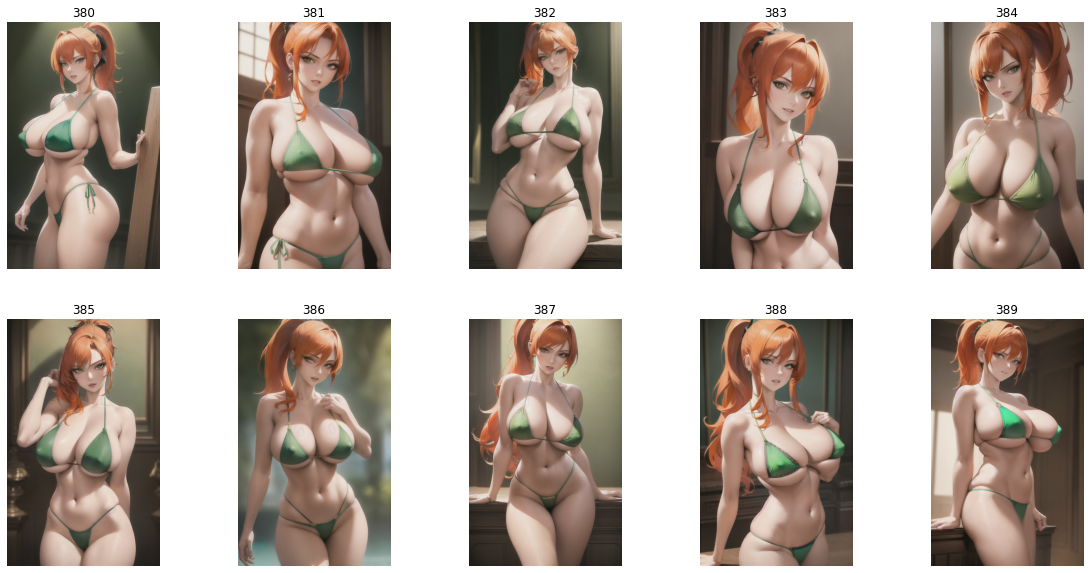

In [ ]:
plot_images(images_0, seeds[:len(images_0)])

In [ ]:
#save_images(images_0, ["AOM2_T0_seed{}_50steps.png".format(seeds[i]) for i in range(len(images_0))])

In [ ]:
SEED = 375
STEPS = 100

images = run_pipe(pipe, prompt_0, negative_prompt_0, steps = STEPS, 
                  width = 512, height = 832, scale = 12, seed = SEED, 
                  n_images = 1, device_name = device_name)

In [ ]:
[display(i) for i in images];

In [ ]:
 #images[0].save("AOM2_BT0_seed{}_{}steps.png".format(SEED, STEPS))